# Naive Bayes Training - Sentimentanalyse Produktrezensionen

Mehrklassen-Klassifizierung (1-5 Sterne) mit TF-IDF und Naive Bayes

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# KONFIGURATION: Project Root
# ============================================================
# Passe den Pfad an, falls das Notebook in einem anderen Verzeichnis liegt
PROJECT_ROOT = Path("../")

# Pfade (relativ zum PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_80_0_20.jsonl"
TEST_FILE = DATA_DIR / "test_0_50000_80_0_20.jsonl"
MODEL_DIR = PROJECT_ROOT / "results" / "models"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

# Ordner erstellen
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Verifikation
print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"TEST_FILE existiert: {TEST_FILE.exists()}")
print("✓ Imports und Pfade initialisiert")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
TEST_FILE existiert: True
✓ Imports und Pfade initialisiert


## 1. Daten laden

In [2]:
def load_data(filepath):
    """Lädt JSONL-Datei und extrahiert title, text, rating"""
    texts = []
    ratings = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            # Kombiniere title und text
            combined_text = f"{data['title']} {data['text']}"
            texts.append(combined_text)
            ratings.append(int(data['rating']))
    
    return texts, ratings

print("Loading training data...")
X_train_texts, y_train = load_data(TRAIN_FILE)
print(f"✓ Trainings-Samples: {len(X_train_texts)}")

print("Loading test data...")
X_test_texts, y_test = load_data(TEST_FILE)
print(f"✓ Test-Samples: {len(X_test_texts)}")

Loading training data...
✓ Trainings-Samples: 160000
Loading test data...
✓ Test-Samples: 40000


## 2. Datenverteilung prüfen

In [3]:
# Class Distribution
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("\nTraining Set Distribution:")
print(train_dist)
print(f"\nTest Set Distribution:")
print(test_dist)


Training Set Distribution:
1      9732
2      6861
3     13470
4     26824
5    103113
Name: count, dtype: int64

Test Set Distribution:
1     2600
2     1634
3     3159
4     6145
5    26462
Name: count, dtype: int64


## 3. TF-IDF Vektorisierung

In [4]:
def preprocess_texts(texts):
    """TF-IDF Vektorisierung"""
    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.95,
        lowercase=True,
        stop_words='english'
    )
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

print("Vektorisierung (TF-IDF)...")
X_train, vectorizer = preprocess_texts(X_train_texts)
X_test = vectorizer.transform(X_test_texts)
print(f"✓ Feature-Dimension: {X_train.shape[1]}")
print(f"✓ Training Matrix Shape: {X_train.shape}")
print(f"✓ Test Matrix Shape: {X_test.shape}")

Vektorisierung (TF-IDF)...
✓ Feature-Dimension: 5000
✓ Training Matrix Shape: (160000, 5000)
✓ Test Matrix Shape: (40000, 5000)


In [8]:
# Optional: Daten rebalancieren für bessere Performance
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(f"Original Training-Samples: {X_train.shape[0]}")
print(f"Resampled Training-Samples: {X_train_resampled.shape[0]}")

Original Training-Samples: 160000
Resampled Training-Samples: 515565


## 4. Naive Bayes Training

In [9]:
def train_model(X_train, y_train, alpha=1.0):
    """Trainiere Naive Bayes Modell"""
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, y_train)
    return model

print("Modell-Training...")
model = train_model(X_train_resampled, y_train_resampled, alpha=1.0)
print("✓ Training abgeschlossen")

Modell-Training...
✓ Training abgeschlossen


## 5. Evaluierung

In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

print(f"\n{'='*60}")
print(f"EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


EVALUIERUNG
Accuracy: 0.6069

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.38      0.69      0.50      2600
     2 Stars       0.15      0.35      0.21      1634
     3 Stars       0.27      0.29      0.28      3159
     4 Stars       0.31      0.31      0.31      6145
     5 Stars       0.87      0.72      0.79     26462

    accuracy                           0.61     40000
   macro avg       0.40      0.47      0.42     40000
weighted avg       0.68      0.61      0.63     40000



## 6. Confusion Matrix Visualisierung

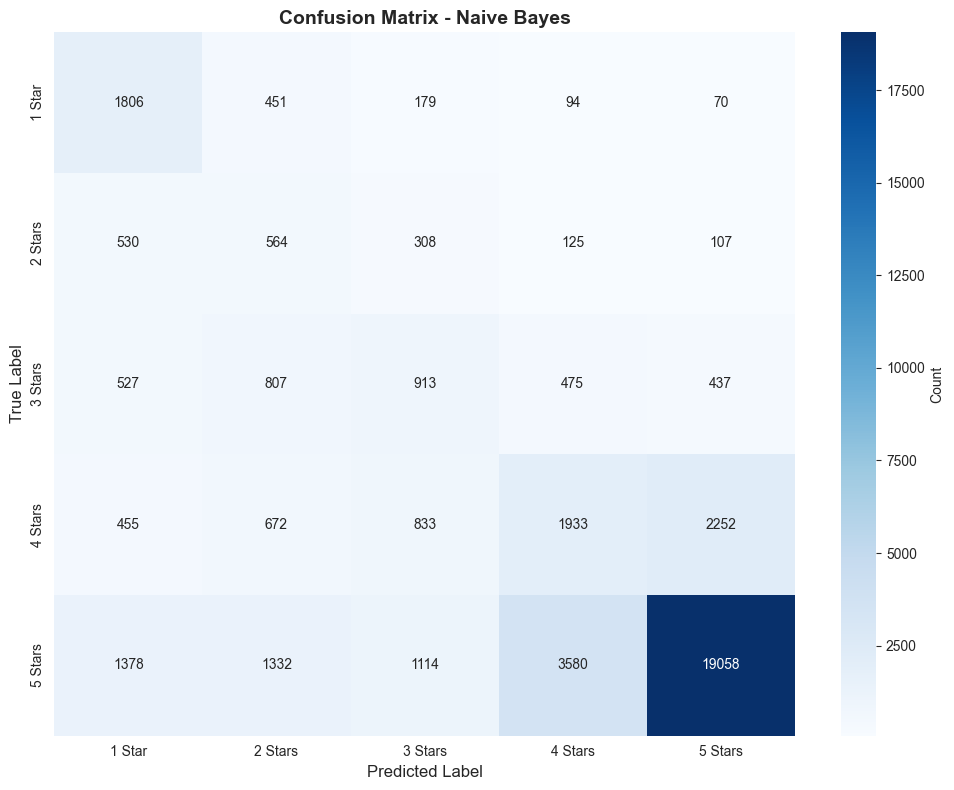

✓ Confusion Matrix gespeichert


In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METRICS_DIR / 'confusion_matrix_naive_bayes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Confusion Matrix gespeichert")

# Confusion Matrix
- **Zeilen** = True Label (was es wirklich ist)
- **Spalten** = Predicted Label (was das Modell sagt)
### Beispielklasse: "5 Stars"
### TP (True Positives) - DIAGONAL
Korrekt als diese Klasse vorhergesagt
- 5 Stars: 19.058
### FP (False Positives) - SPALTE (ohne Diagonal)
Falsch als diese Klasse klassifiziert
- 5 Stars: 70 + 107 + 437 + 2.252 = 2.866
### FN (False Negatives) - ZEILE (ohne Diagonal)
Sollte diese Klasse sein, aber nicht vorhergesagt
- 5 Stars: 1.378 + 1.332 + 1.114 + 3.580 = 7.404
### TN (True Negatives)
Korrekt als NICHT diese Klasse klassifiziert
- Alles außer Zeile und Spalte dieser Klasse
```

## 7. Modell und Ergebnisse speichern

In [12]:
# Metriken speichern
results = {
    'accuracy': float(accuracy),
    'confusion_matrix': conf_matrix.tolist(),
    'num_test_samples': len(y_test),
    'classes': class_names,
    'alpha': 1.0
}

with open(METRICS_DIR / "naive_bayes_metrics.json", 'w') as f:
    json.dump(results, f, indent=2)

# CSV für Vergleiche
metrics_df = pd.DataFrame({
    'Model': ['Naive Bayes'],
    'Accuracy': [accuracy],
    'Test_Samples': [len(y_test)],
    'Alpha': [1.0]
})
metrics_df.to_csv(METRICS_DIR / "naive_bayes_results.csv", index=False)

# Modell speichern
with open(MODEL_DIR / "naive_bayes_model.pkl", 'wb') as f:
    pickle.dump(model, f)
with open(MODEL_DIR / "vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✓ Metriken gespeichert in {METRICS_DIR}")
print(f"✓ Modell gespeichert in {MODEL_DIR}")

✓ Metriken gespeichert in ..\results\metrics
✓ Modell gespeichert in ..\results\models


## 8. Hyperparameter-Tuning (Optional)

In [13]:
# Teste verschiedene Alpha-Werte
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
results_alpha = []

print("Testing verschiedene Alpha-Werte...\n")
for alpha in alphas:
    model_temp = train_model(X_train, y_train, alpha=alpha)
    y_pred_temp = model_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    results_alpha.append({'alpha': alpha, 'accuracy': acc})
    print(f"Alpha: {alpha:6.2f} → Accuracy: {acc:.4f}")

results_alpha_df = pd.DataFrame(results_alpha)
print(f"\nBeste Alpha: {results_alpha_df.loc[results_alpha_df['accuracy'].idxmax(), 'alpha']:.2f}")

Testing verschiedene Alpha-Werte...

Alpha:   0.01 → Accuracy: 0.6942
Alpha:   0.10 → Accuracy: 0.6940
Alpha:   0.50 → Accuracy: 0.6927
Alpha:   1.00 → Accuracy: 0.6910
Alpha:   5.00 → Accuracy: 0.6788
Alpha:  10.00 → Accuracy: 0.6708

Beste Alpha: 0.01


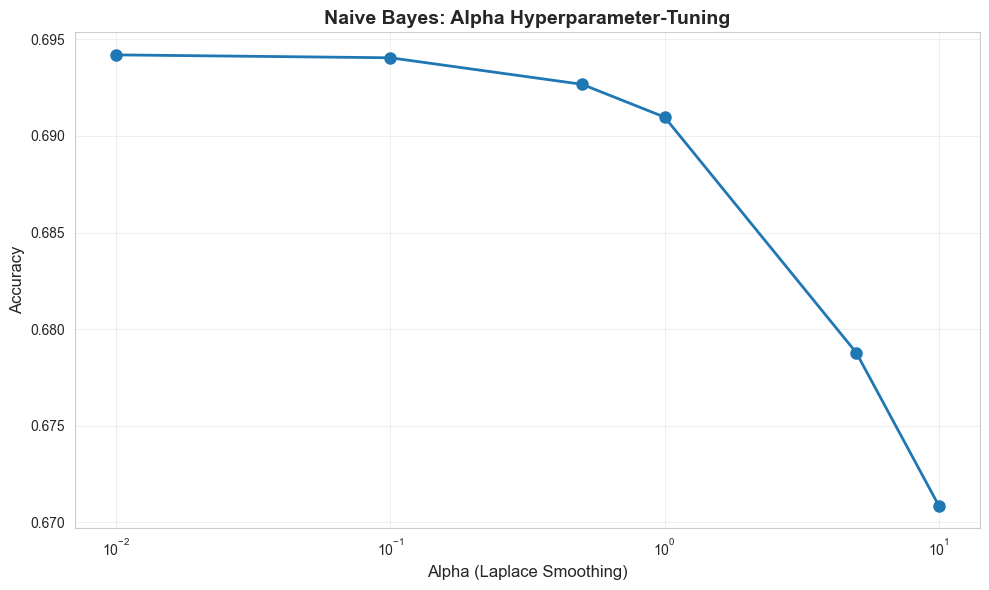

In [14]:
# Visualisiere Alpha-Ergebnisse
plt.figure(figsize=(10, 6))
plt.plot(results_alpha_df['alpha'], results_alpha_df['accuracy'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Alpha (Laplace Smoothing)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Naive Bayes: Alpha Hyperparameter-Tuning', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig(METRICS_DIR / 'alpha_tuning.png', dpi=300, bbox_inches='tight')
plt.show()